# Comparaison d'embeddings des deux graphes

In [ ]:
from node2vec import Node2Vec
import pickle
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
import networkx as nx
import seaborn as sns
import plotly.express as px
import pandas as pd

## Importation des deux graphes

In [7]:
with open('Q174606.pickle', 'rb') as f:
    G1 = pickle.load(f)
G1 = G1.to_undirected()

dico_periods1 = {}
for node in G1.nodes():
    period = node.get_era()
    if period not in dico_periods1:
        dico_periods1[period] = [node]
    else:
        dico_periods1[period].append(node)
del dico_periods1['Unknown']

In [9]:
with open('graphe_centroids_pot_seuil=1.3.pkl', 'rb') as f:
    G2 = pickle.load(f)
G2 = G2.to_undirected()

def periode(str):
    try:
        date_deb = int(str[0:4])
        date_end = str[5:9]
        if date_deb is None :
            return "Unknown"
        elif date_deb < 1570 and date_deb > 476:
            return "Medieval"
        elif date_deb < 1730:
            return "Baroque"
        elif date_deb < 1800:
            return "Classique"
        elif date_deb < 1860:
            return "Romantique"
        else:
            try:
                date_end = int(date_end)
                return "XXe"
            except:
                return "contemporain"
    except :
        return "Unknown"
    
def dico_filenames(filename = "cross-era_annotations.csv"):
    dico = {}
    df = pd.read_csv(filename, sep=',')
    for i in range(len(df)):
        per = periode(df['CompLifetime'][i])
        #print(df['Composer'][i],df['CompLifetime'][i],per)
        composer = df['Composer'][i]
        if per not in dico:
            dico[per] = [df['Composer'][i]]
        else:
            dico[per].append(df['Composer'][i])
    for key,item in dico.items():
        dico[key] = list(set(item))
    del dico['Unknown']
    return dico

dico_periods2 = dico_filenames()

## Obtention des embeddings

In [16]:
def get_node2vec_embeddings(G, dimensions=16):
    node2vec = Node2Vec(G, dimensions=dimensions, walk_length=10, num_walks=100, workers=1, quiet=True)
    model = node2vec.fit(window=5, min_count=1, batch_words=4)
    embeddings = np.array([model.wv[str(i)] for i in G.nodes()])
    return embeddings

emb_G1 = get_node2vec_embeddings(G1)
emb_G2 = get_node2vec_embeddings(G2)

In [18]:
with open('embeddings_G1.pkl', 'wb') as f:
    pickle.dump(emb_G1, f)
with open('embeddings_G2.pkl', 'wb') as f:
    pickle.dump(emb_G2, f)

In [ ]:
with open('embeddings_G1.pkl', 'wb') as f:
    pickle.load(emb_G1, f)
with open('embeddings_G2.pkl', 'wb') as f:
    pickle.load(emb_G2, f)

In [19]:
emb_G1

array([[-0.23091155,  0.39993423,  0.48254332, ..., -0.88670385,
        -1.1864549 ,  1.2647315 ],
       [ 0.41359237,  0.42608845,  1.164853  , ..., -0.6299983 ,
        -1.3647964 ,  1.2480859 ],
       [-0.30128732,  0.39760834,  0.66815615, ..., -1.3106492 ,
        -1.296773  ,  1.6723254 ],
       ...,
       [-1.845739  , -1.5001494 , -0.7001752 , ..., -0.8110844 ,
         0.49342203,  1.9954845 ],
       [-2.2017763 , -2.6019034 , -0.5699592 , ..., -2.1385946 ,
         0.14126797,  0.90415376],
       [ 0.70149606, -1.544443  ,  0.7611902 , ..., -0.6061208 ,
        -0.9723427 ,  0.14590259]], dtype=float32)

In [20]:
def compute_mmd(X, Y, gamma=1.0):
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

In [21]:
def permutation_test_mmd(X, Y, gamma=1.0, n_permutations=500):
    combined = np.vstack([X, Y])
    true_mmd = compute_mmd(X, Y, gamma=gamma)
    mmds_random = []

    for _ in range(n_permutations):
        np.random.shuffle(combined)
        A, B = combined[:len(X)], combined[len(X):]
        mmds_random.append(compute_mmd(A, B, gamma=gamma))

    p_value = np.mean(np.array(mmds_random) >= true_mmd)
    return true_mmd, p_value, mmds_random

In [22]:
true_mmd, p_val, mmds_random = permutation_test_mmd(emb_G1, emb_G2, gamma=1.0)

✅ MMD observé : 0.2710
📊 p-value empirique : 0.0000


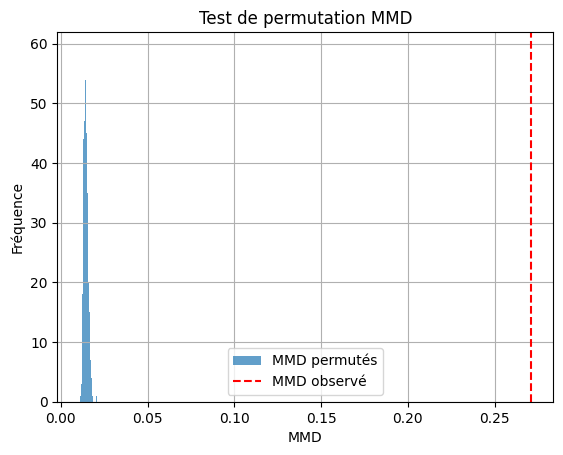

In [ ]:
import pandas as pd
from functools import partial

emb_all = np.vstack([emb_G1, emb_G2])

labels = ['G1'] * len(emb_G1) + ['G2'] * len(emb_G2)
composers = list([node.name for node in G1.nodes()]) + list([node for node in G2.nodes()])

pca = PCA(n_components=3)
emb_3d = pca.fit_transform(emb_all)

fig = px.scatter_3d(
    x=emb_3d[:, 0], y=emb_3d[:, 1], z=emb_3d[:, 2],
    color=labels, title="Visualisation 3D des embeddings Node2Vec (PCA)",
    labels={"color": "Graphe"}, opacity=0.8, text = composers
)
fig.show()

✅ MMD observé : 0.2710
📊 p-value empirique : 0.0000


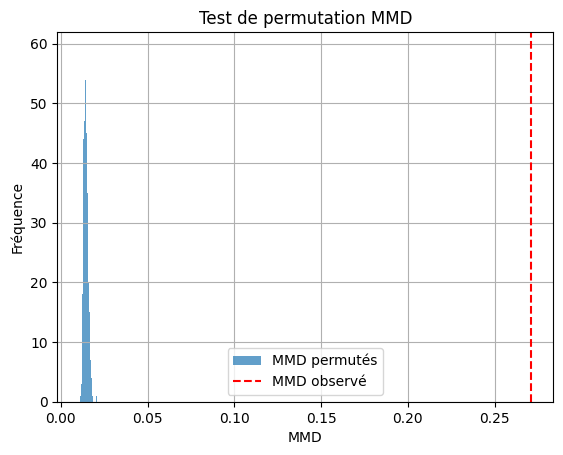

In [32]:
# Étape 6 : Afficher les résultats
print(f"✅ MMD observé : {true_mmd:.4f}")
print(f"📊 p-value empirique : {p_val:.4f}")

# Optionnel : visualiser la distribution des MMD aléatoires
plt.hist(mmds_random, bins=30, alpha=0.7, label="MMD permutés")
plt.axvline(true_mmd, color='red', linestyle='--', label='MMD observé')
plt.title("Test de permutation MMD")
plt.xlabel("MMD")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True)
plt.show()